In [1]:
import warnings
from pathlib import Path
import json
import re
from multiprocessing import Pool

import numpy as np  

import corner

# Support for interactive widgets
from IPython.display import *
from ipywidgets import Dropdown

# %matplotlib widget 
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", "Using UFloat objects with std_dev==0 may give unexpected results.", category=UserWarning)
from uncertainties import ufloat
from uncertainties.unumpy import nominal_values
import astropy.units as u
from astropy.coordinates import SkyCoord
from astroquery.simbad import Simbad
from astroquery.vizier import Vizier
from astroquery.gaia import Gaia

from dust_extinction.parameter_averages import F99, F04, G23

from deblib.constants import M_sun, R_sun
from deblib.stellar import log_g

from support import extinction
from support.pipeline import get_teff_from_spt
from support.sed import get_sed_for_target, create_outliers_mask, group_and_average_fluxes
from support.plots import plot_sed, plot_fitted_model

from sed_fit.fitter import create_theta, minimize_fit, mcmc_fit
from sed_fit.stellar_grids import BtSettlGrid

### Set up the extinction model

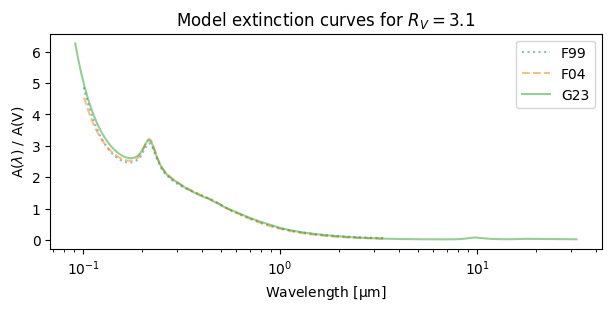

Using the G23 extinction model covers the range from 0.0912 µm to 32.0 µm.


In [2]:
fig, ax = plt.subplots(1, 1, figsize=(6, 3), constrained_layout=True)
for (_mod, _ls) in [(F99, ":"), (F04, "--"), (G23, "-")]:
    _lambda = (1 / np.logspace(*np.log10(_mod.x_range), num=1000)) * u.um
    ax.plot(_lambda, _mod(Rv=3.1)(_lambda), ls=_ls, alpha=0.5, label=f"{_mod.name}")
ax.set(title=f"Model extinction curves for $R_V=3.1$", xscale="log",
       xlabel=f"Wavelength [{_lambda.unit:latex_inline}]", ylabel=r"A($\lambda$) / A(V)")
ax.legend(loc="best")
plt.show(fig)
plt.close(fig)

# The G23 (Gordon et al., 2023) Milky Way R(V) filter gives us the broadest coverage
ext_model = G23(Rv=3.1)
ext_wl_range = np.reciprocal(ext_model.x_range) * u.um # x_range has implicit units of 1/micron
print(f"Using the {ext_model.__class__.__name__} extinction model covers the range from",
      f"{min(ext_wl_range):unicode} to {max(ext_wl_range):unicode}.")

### Load the bt-settle-agss grids and set up the related model functions 

The ModelSed loads a grid of pre-filtered fluxes across a range of $T_{\rm eff}$, $\log{g}$ and 
metallicities into a `RegularGridInterpolator`s, one per filter.

For now we consider only the data for solar metallicity, hence the interpolators only cover
$[{\rm Fe/H}] = 0$ and $[{\rm \alpha/Fe}] = 0$, however additional axes/dimensions
for $[{\rm Fe/H}]$ and $[{\rm \alpha/Fe}]$ may be added, if required.

In [3]:
# Model SED grid based on bt-settl-agss models with known filters pre-applied to non-reddened fluxes
data_file = Path("./sed_fit/data/stellar_grids/bt-settl-agss/bt-settl-agss.npz")
model_grid = BtSettlGrid(data_file=data_file, extinction_model=ext_model, verbose=True)

print(f"Loaded grid based on bt-settl models, covering the ranges:")
print(f"wavelength {model_grid.wavelength_range * model_grid.wavelength_unit:unicode},",
      f"Teff {model_grid.teff_range * model_grid.teff_unit:unicode},",
      f"logg {model_grid.logg_range * model_grid.logg_unit:unicode}",
      f"\nand metallicity {model_grid.metal_range * u.dimensionless_unscaled:unicode},",
      f"with fluxes returned in units of {model_grid.flux_unit:unicode}")

Loading model grid from bt-settl-agss.npz created at 2025-11-19 15:08:30.608023+00:00
BtSettlGrid is initializing the fluxes interpolator with the grid of 112 teff, 6 logg & 4 metal values and 5000 wavelength bins...will use slinear interpolation...done.
Initializing unreddened fluxes for 39 filters.......................................done.
Loaded grid based on bt-settl models, covering the ranges:
wavelength [ 0.09120575 31.99861909] µm, Teff [ 2000. 40000.] K, logg [3.  5.5] dex 
and metallicity [-0.5  0.5], with fluxes returned in units of W m⁻²


### Select our target and get its known information

In [4]:
default_target = "AI Phe"
targets_config_file = Path.cwd() / "config" / "fitting-a-sed-targets.json"
with open(targets_config_file, mode="r", encoding="utf8") as f:
    full_dict = json.load(f)
targets_cfg = { k: full_dict[k] for k in full_dict if full_dict[k].get("enabled", True) }

max_teff = max(model_grid.teff_range * model_grid.teff_unit).to(u.K).value
options = [
    (f"{t}" + (" *" if c.get("exclude", False) else "") + (" [too hot!]" if min(c["Teff1"], c["Teff2"]) > max_teff else ""), t)
        for t, c in targets_cfg.items()
]

target_selection = Dropdown(options=options, value=default_target, description="Targets:")
display(target_selection)

Dropdown(description='Targets:', index=25, options=(('V436 Per', 'V436 Per'), ('V539 Ara', 'V539 Ara'), ('MU C…

In [5]:
target = target_selection.value
target_config = targets_cfg[target]
target_config.setdefault("logg1", log_g(target_config["M1"] * M_sun, target_config["R1"] * R_sun).n)
target_config.setdefault("logg2", log_g(target_config["M2"] * M_sun, target_config["R2"] * R_sun).n)

# Additional data on the target populated with lookups
target_data = {
    "label": target_config.get("label", target),
    "search_term": target_config.get("search_term", target)
}

_simbad = Simbad()
_simbad.add_votable_fields("sp", "ids")
if _tbl := _simbad.query_object(target_data["search_term"]):
    target_data["ids"] = np.array(re.findall(r"(Gaia DR3|V\*|TIC|HD|HIP|2MASS)\s+(.+?(?=\||$))", _tbl["ids"][0]),
                                    dtype=[("type", object), ("id", object)])
    print(f"IDs:", ", ".join(f"{i['type']} {i['id']}" for i in target_data["ids"]))
    target_data["spt"] = _tbl["sp_type"][0]
    print(f"SpT:", target_data["spt"])

IDs: TIC 102069549, HIP 5438, Gaia DR3 4933562966514402176, 2MASS J01093419-4615560, HD 6980, V* BV  1513, V* AI Phe
SpT: G3V


In [6]:
# Let's get the Gaia DR3 data on this here object
_gaia_dr3_id = target_data["ids"][target_data["ids"]["type"] == "Gaia DR3"]["id"][0]
if _job := Gaia.launch_job(f"SELECT TOP 1 * FROM gaiadr3.gaia_source WHERE source_id = {_gaia_dr3_id}"):
    _tbl = _job.get_results()
    target_data["parallax_mas"] = ufloat(_tbl["parallax"][0], _tbl["parallax_error"][0])
    target_data["skycoords"] = _coords = SkyCoord(ra=_tbl["ra"][0] * u.deg, dec=_tbl["dec"][0] * u.deg,
                                                  distance=1000 / _tbl["parallax"][0] * u.pc, frame="icrs")
    print(f"{target} SkyCoords are {_coords} (or {_coords.to_string('hmsdms')})")
    target_data["bp_rp"] = _tbl["bp_rp"][0]
    target_data["phot_g_mean_mag"] = _tbl["phot_g_mean_mag"][0]
    target_data["ruwe"] = _tbl["ruwe"][0]
    print(f"ruwe = {target_data.get('ruwe', 0):.3f}")

AI Phe SkyCoords are <SkyCoord (ICRS): (ra, dec, distance) in (deg, deg, pc)
    (17.39283047, -46.26557313, 169.29466543)> (or 01h09m34.27931365s -46d15m56.06325506s)
ruwe = 1.149


In [7]:
# Lookup the TESS Input Catalog (8.2) for starting "system" Teff and logg values
target_data["teff_sys"] = get_teff_from_spt(target_data["spt"]) or ufloat(5700, 0)
target_data["logg_sys"] = ufloat(4.0, 0)
if _tbl := Vizier(catalog="IV/39/tic82").query_object(target_data["search_term"], radius=0.1 * u.arcsec):
    if _row := _tbl[0][_tbl[0]["TIC"] in target_data["ids"][target_data["ids"]["type"] == "TIC"]["id"]]:
        # Teff may not be reliable - only use it if it's consistent with the SpT
        if target_data["teff_sys"].n-target_data["teff_sys"].s < (_row["Teff"] or 0) < target_data["teff_sys"].n+target_data["teff_sys"].s:
            target_data["teff_sys"] = ufloat(_row["Teff"], _row.get("s_Teff", None) or 0)
        if (_row["logg"] or 0) > 0:
            target_data["logg_sys"] = ufloat(_row["logg"], _row.get("s_logg", None) or 0)

# Other priors will likely come out of light curve fitting with JKTEBOP - get from config for now
target_data["k"] = ufloat(target_config.get("k"), target_config.get("k_err", 0) or 0)
if "light_ratio" in target_config:
    target_data["light_ratio"] = ufloat(target_config.get("light_ratio"), target_config.get("light_ratio_err", 0) or 0)
else:
    # If from LC fit we may also need to consider 3L; l1=(1-3L)/(1+(L2/L1)) & l2=(1-3L)/(1+1/(L2/L1))
    target_data["light_ratio"] = ufloat(10**(target_config.get("logL2", 1) - target_config.get("logL1", 1)), 0)
target_data["teff_ratio"] = (target_data["light_ratio"] / target_data["k"]**2)**0.25

print(f"{target} system values from lookup and LC fitting:")
for p, unit in [("teff_sys", u.K), ("logg_sys", u.dex), ("k", None), ("light_ratio", None), ("teff_ratio", None)]:
    print(f"{p:>12s} = {target_data[p]:.3f} {unit or u.dimensionless_unscaled:unicode}")

AI Phe system values from lookup and LC fitting:
    teff_sys = 5588.000+/-127.000 K
    logg_sys = 4.000+/-0 dex
           k = 1.625+/-0.003 
 light_ratio = 1.112+/-0 
  teff_ratio = 0.805+/-0.001 


### Get the SED data for the target
- apply default uncertainties to those measurements with none
- remove duplicate SED measurements
- group and average SED measurements by filter & frequency
- exclude measurements outside the range of our extinction model
- optionally exclude flux outliers

In [8]:
# Read in the SED for this target and de-duplicate (measurements may appear multiple times).
sed = get_sed_for_target(target, target_data["search_term"], radius=0.1, remove_duplicates=True,
                         freq_unit=u.GHz, flux_unit=u.Jy, wl_unit=u.um, verbose=True)

sed = group_and_average_fluxes(sed, verbose=True)

# Filter SED to those covered by our models and also remove any outliers
model_mask = np.ones((len(sed)), dtype=bool)
model_mask &= model_grid.has_filter(sed["sed_filter"])
model_mask &= (sed["sed_wl"] >= min(ext_wl_range)) \
            & (sed["sed_wl"] <= max(ext_wl_range)) \
            & (sed["sed_wl"] >= min(model_grid.wavelength_range)) \
            & (sed["sed_wl"] <= max(model_grid.wavelength_range)) \
            & (sed["sed_wl"] <= 22 * u.um)
sed = sed[model_mask]

out_mask = create_outliers_mask(sed, target_data["teff_sys"].n, [target_data["teff_ratio"].n],
                                min_unmasked=15, verbose=True)
sed = sed[~out_mask]

sed.sort(["sed_wl"])
print(f"{len(sed)} unique SED observation(s) retained after range and outlier filtering",
      "\nwith the units for flux density, frequency and wavelength being",
      ", ".join(f"{sed[f].unit:unicode}" for f in ["sed_flux", "sed_freq", "sed_wl"]))
print("Filters (by wavelength):", ", ".join(sed["sed_filter"]))

Opened SED table ai-phe-0.1.vot containing 96 row(s).
Dropped 47 duplicate(s) leaving 49 unique row(s).
Grouped SED by ['sed_filter', 'sed_freq'] yielding 21 group(s) from 49 row(s).
Calculating the group means of the [('sed_flux', 'sed_eflux')] columns
No outliers masked as already 15 or fewer SED rows
13 unique SED observation(s) retained after range and outlier filtering 
with the units for flux density, frequency and wavelength being Jy, GHz, µm
Filters (by wavelength): Johnson:B, Johnson:V, Gaia:G, 2MASS:J, Johnson:J, Johnson:H, 2MASS:H, 2MASS:Ks, Johnson:K, WISE:W1, Johnson:L, WISE:W2, WISE:W3


### De-redden the SED
Use the target coordinates to find an $E(B-V)$ value from the available extinction maps.
With this we can deredden the remaining SED fluxes using the previously created extinction model.

We have the option of fit for the extinction value ${\rm A_V}$, however this significantly slows
the fitting algorithms as the extinction effect must be calculated for each step/iteration.
If you have sufficient confidence in the lookup value it is much quicker to use it to deredden
the SED in advance and run the fitting with ${\rm A_V}$ fixed at zero.

In [9]:
for val, flags in extinction.get_ebv(target_data["skycoords"], rv=ext_model.Rv):
    if val and not np.isnan(val) and flags.get("converged", False):
        print(f"Found extinction with {flags['source']}: E(B-V) = {val:.6f}")
        sed["sed_der_flux"] = sed["sed_flux"] / ext_model.extinguish(sed["sed_wl"].to(u.um), Ebv=val)
        break

if "sed_der_flux" in sed.colnames:
    der_lab = "dereddened"
else:
    sed["sed_der_flux"] = sed["sed_flux"]
    der_lab = "not dereddened"

Checking existing file to see if MD5 sum matches ...
File exists. Not overwriting.
Loading pixel_info ...
Loading samples ...
Loading best_fit ...
Replacing NaNs in reliable distance estimates ...
Sorting pixel_info ...
Extracting hp_idx_sorted and data_idx at each nside ...
  nside = 64
  nside = 128
  nside = 256
  nside = 512
  nside = 1024
t = 27.164 s
  pix_info:   0.376 s
   samples:  15.382 s
      best:   3.068 s
       nan:   0.030 s
      sort:   8.215 s
       idx:   0.093 s
Querying Galactic interstellar dust Gaia-2MASS 3D maps (2022A&A...664A.174V) for extinction data.
Found extinction with get_vergely_av: E(B-V) = 0.001968


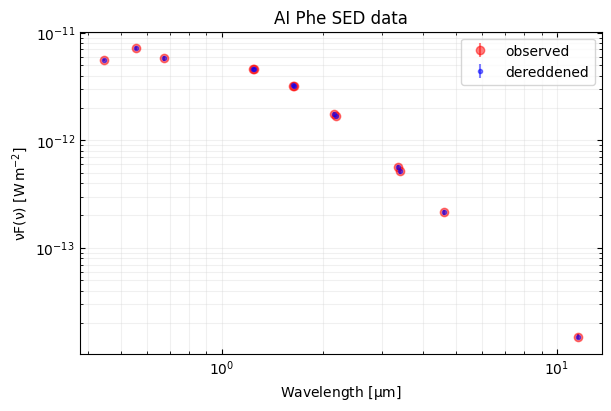

In [10]:
fig = plot_sed(sed["sed_wl"].quantity,
               fluxes=[sed["sed_flux"].quantity, sed["sed_der_flux"].quantity],
               flux_errs=[sed["sed_eflux"].quantity]*2,
               fmts=["or", ".b"],
               labels=["observed", der_lab],
               title=target_data['label'] + " SED data")
plt.show(fig)
plt.close(fig)

### Set up the functions which will support fitting

In [11]:
NUM_STARS = 2

theta_plot_labels = np.array([f"$T_{{\\rm eff,{st+1}}} / {{\\rm K}}$" for st in range(NUM_STARS)] \
                            +[f"$\\log{{g}}_{{\\rm {st+1}}}$" for st in range(NUM_STARS)] \
                            +[f"$R_{{\\rm {st+1}}} / {{\\rm R_{{\\odot}}}}$" for st in range(NUM_STARS)] \
                            +["${\\rm distance} / {\\rm pc}$", "${\\rm A_{V}}$"])

theta_labels = np.array([(f"Teff{st+1}", u.K) for st in range(NUM_STARS)] \
                        +[(f"logg{st+1}", u.dex) for st in range(NUM_STARS)] \
                        +[(f"R{st+1}", u.Rsun) for st in range(NUM_STARS)] \
                        +[("dist", u.pc), ("av", u.dimensionless_unscaled)])

We set the starting position for the fit, `theta0`, which is our best estimate of the
fitted values for the system based on existing published data and any light-curve fitting carried
out previously.

The `fit_mask` indicates which of the values in `theta0` is fitted, with the remainder being fixed.

In [12]:
theta0 = create_theta(teffs=[target_data["teff_sys"].n] * NUM_STARS,
                      loggs=[target_data["logg_sys"].n] * NUM_STARS,
                      radii=[1.0] * NUM_STARS,
                      dist=target_data["skycoords"].distance.to(u.pc).value,
                      av=0,
                      nstars=NUM_STARS,
                      verbose=True)

fit_mask = np.array([True] * NUM_STARS      # teff
                  + [False] * NUM_STARS     # logg
                  + [True] * NUM_STARS      # radius
                  + [False]                 # dist
                  + [False])                # av (we've handled av by derredening the SED)

print(f"For {target} we set the starting position (theta0) to be:",
    *(f"\n{l:>9s} = {theta0[ix]:.3f} {unit:unicode}" for ix, (l, unit) in enumerate(theta_labels)))

theta:	 5.588e+03, 5.588e+03, 4.000e+00, 4.000e+00, 1.000e+00, 1.000e+00, 1.693e+02, 0.000e+00
For AI Phe we set the starting position (theta0) to be: 
    Teff1 = 5588.000 K 
    Teff2 = 5588.000 K 
    logg1 = 4.000 dex 
    logg2 = 4.000 dex 
       R1 = 1.000 R☉ 
       R2 = 1.000 R☉ 
     dist = 169.295 pc 
       av = 0.000 


Here we set up priors' limit and ratio criteria for the fitting. This is in the form of a
callback function which the fitting code invokes at the start of each iteration.

In [ ]:
teff_limits = model_grid.teff_range
radius_limits = (0.1, 100)

# Ratios wrt the primary component
teff_ratios = [1] + [ufloat(target_data["teff_ratio"].n,
                            max(target_data["teff_ratio"].n * 0.05, target_data["teff_ratio"].s))] * (NUM_STARS - 1)
rad_ratios = [1] + [ufloat(target_data["k"].n,
                           max(target_data["k"].n * 0.05, target_data["k"].s))] * (NUM_STARS - 1)

# Distance & AV priors - only effect the outcome if these are fitted
dist_prior = ufloat(theta0[-2], theta0[-2] * 0.05)
av_prior = ufloat(theta0[-1], theta0[-1] * 0.05)

def ln_prior_func(theta: np.ndarray[float]) -> float:
    """
    The fitting prior callback function to evaluate the current set of candidate
    parameters (theta), returning a single ln(value) indicating their "goodness".
    """
    teffs = theta[0 : NUM_STARS]
    radii = theta[2*NUM_STARS : 2*NUM_STARS + NUM_STARS]
    # dist, av = theta[-2], theta[-1]

    # Limit criteria checks - hard pass/fail on these
    if not all(teff_limits[0] <= t <= teff_limits[1] for t in teffs) or \
        not all(radius_limits[0] <= r <= radius_limits[1] for r in radii):
        return np.inf

    # Gaussian prior criteria: g(x) = 1/(σ*sqrt(2*pi)) * exp(-1/2 * (x-µ)^2/σ^2)
    # Omitting scaling expressions and note the implicit ln() cancelling the exp()
    ret_val = 0
    for star_ix in range(1, NUM_STARS): # Ratios
        ret_val += ((teffs[star_ix]/teffs[0] - teff_ratios[star_ix].n) / teff_ratios[star_ix].s)**2
        ret_val += ((radii[star_ix]/radii[0] - rad_ratios[star_ix].n) / rad_ratios[star_ix].s)**2
    # ret_val += ((dist - dist_prior.n) / dist_prior.s)**2
    # ret_val += ((av - av_prior.n) / av_prior.s)**2
    return 0.5 * ret_val

Get the observed SED data into a format for fitting.

In [14]:
# Prepare the data to be fitted
x = model_grid.get_filter_indices(sed["sed_filter"])
y = (sed["sed_der_flux"].quantity * sed["sed_freq"].quantity)\
                                    .to(model_grid.flux_unit, equivalencies=u.spectral()).value
y_err = (sed["sed_eflux"].quantity * sed["sed_freq"].quantity)\
                                    .to(model_grid.flux_unit, equivalencies=u.spectral()).value

### Initial (quick) minimize fit.

In [15]:
theta_min, soln = minimize_fit(x, y, y_err=y_err, theta0=theta0, fit_mask=fit_mask,
                               ln_prior_func=ln_prior_func, stellar_grid=model_grid, verbose=True)

minimize_fit(theta0=[5.588e+03*, 5.588e+03*, 4.000e+00, 4.000e+00, 1.000e+00*, 1.000e+00*, 1.693e+02, 0.000e+00])
(Nelder-Mead) succeeded after 182 iterations & 314 function evaluation(s) [fun = 1.685767]
(SLSQP) succeeded after 39 iterations & 207 function evaluation(s) [fun = 1.685767]
(None) succeeded after 49 iterations & 375 function evaluation(s) [fun = 1.685767]
The best fit with Nelder-Mead method yielded theta=[6.243e+03*, 4.985e+03*, 4.000e+00, 4.000e+00, 1.830e+00*, 2.973e+00*, 1.693e+02, 0.000e+00]


Best fit parameters for AI Phe from the 'minimize' fit
       Teff1 = 6243.254 K (known value 6257.000+/-0)
       Teff2 = 4984.667 K (known value 5100.000+/-0)
          R1 = 1.830 R☉ (known value 1.805+/-0.002)
          R2 = 2.973 R☉ (known value 2.933+/-0.002)


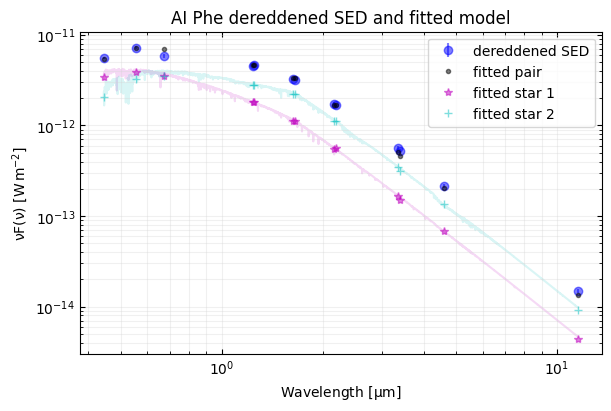

In [16]:
print(f"Best fit parameters for {target} from the 'minimize' fit")
for ix, (l, unit) in enumerate(theta_labels[fit_mask]):
    known_val = ufloat(target_config.get(l, np.NaN), target_config.get(l + "_err", None) or 0)
    print(f"{l:>12s} = {theta_min[fit_mask][ix]:.3f} {unit:unicode} (known value {known_val:.3f})")

fig = plot_fitted_model(sed, theta_min, model_grid,
                        title=f"{target_data['label']} dereddened SED and fitted model")
plt.show(fig)
plt.close(fig)

### Perform MCMC fitting for a more reliable fit with uncertainties from a probability distribution

In [17]:
thin_by = 10 # sample every nth step from the chain
theta_mcmc, sampler = mcmc_fit(x, y, y_err, theta0=theta_min, fit_mask=fit_mask,
                               ln_prior_func=ln_prior_func, stellar_grid=model_grid, 
                               nwalkers=100, nsteps=100000, thin_by=thin_by, seed=42,
                               early_stopping=True, processes=8, progress=True, verbose=True)

mcmc_fit(theta0=[6.243e+03*, 4.985e+03*, 4.000e+00, 4.000e+00, 1.830e+00*, 2.973e+00*, 1.693e+02, 0.000e+00])
Running MCMC fit with 100 walkers for 100000 steps, thinned by 10, on 8 process(es). Early stopping is enabled after 2500 steps.


  9%|▉         | 9000/100000 [04:18<43:37, 34.76it/s]


Halting MCMC after 9000 steps as the walkers are past 100 times the autocorrelation time & the fit has converged.
Autocorrelation steps (tau): 46.964, 46.996, 49.478, 45.703
Estimated burn-in steps:     98
Mean Acceptance fraction:    0.592
The MCMC fit yielded theta:  [(6.227+/-0.145)e+03*, (4.981+/-0.157)e+03*, (4.000+/-0)e+00, (4.000+/-0)e+00, (1.837+/-0.078)e+00*, (2.973+/-0.076)e+00*, (1.693+/-0)e+02, (0.000+/-0)e+00]


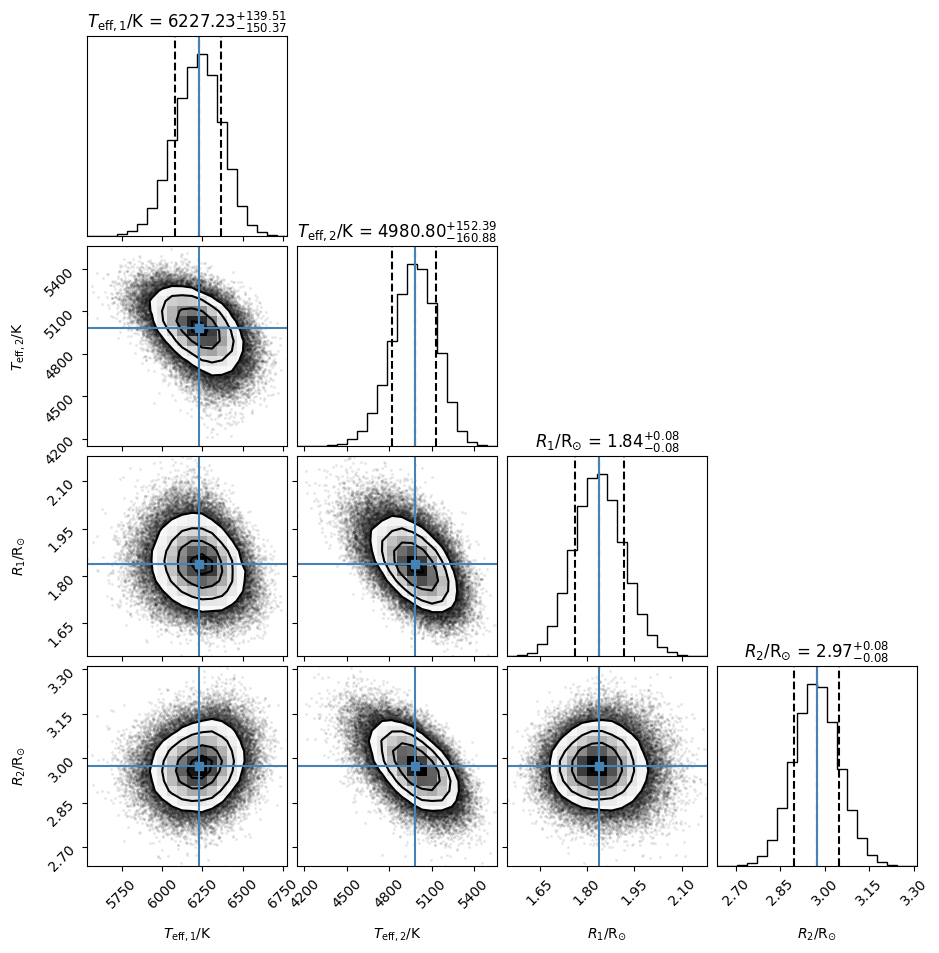

In [18]:
tau = sampler.get_autocorr_time(c=5, tol=50, quiet=True) * thin_by
burn_in_steps = int(max(np.nan_to_num(tau, copy=True, nan=1000)) * 2)
samples = sampler.get_chain(discard=burn_in_steps, flat=True)
plt.show(corner.corner(samples, show_titles=True, plot_datapoints=True, quantiles=[0.16, 0.5, 0.84],
                       labels=theta_plot_labels[fit_mask], truths=nominal_values(theta_mcmc[fit_mask])))
plt.close()


Final parameters for AI Phe with nominals & 1-sigma error bars from MCMC fit
       Teff1 = 6227.251+/-144.915 K (known value 6257.000+/-0 K)
       Teff2 = 4980.792+/-156.604 K (known value 5100.000+/-0 K)
          R1 = 1.837+/-0.078 R☉ (known value 1.805+/-0.002 R☉)
          R2 = 2.973+/-0.076 R☉ (known value 2.933+/-0.002 R☉)


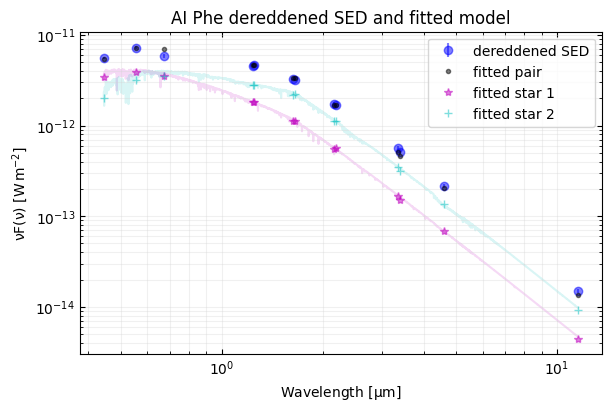

In [19]:
print(f"\nFinal parameters for {target} with nominals & 1-sigma error bars from MCMC fit")
for (param, unit), fit in zip(theta_labels[fit_mask], theta_mcmc[fit_mask]):
    known = ufloat(target_config.get(param, np.NaN), target_config.get(param+"_err", None) or 0)
    print(f"{param:>12s} = {fit:.3f} {unit:unicode} (known value {known:.3f} {unit:unicode})")

fig = plot_fitted_model(sed, theta_mcmc, model_grid,
                        title=f"{target_data['label']} dereddened SED and fitted model")
plt.show(fig)
plt.close(fig)